## Supervisior Multi

In [12]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
from pprint import pprint
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6")

In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.types import Command

from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain.agents import create_agent

from operator import add
from typing import TypedDict, Annotated, Literal

from langchain_tavily import TavilySearch
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
duckduckgo_tool = DuckDuckGoSearchRun()

In [4]:
result = duckduckgo_tool.invoke('Quant Finance')
word_count = len(result.split())
print("Number of words:", word_count)

Number of words: 122


In [8]:
@tool(description = 'Searches DuckDuckGo for a given query adn returns the result')
def search_duckduckgo(query: str):
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

@tool(description='Add two numbers')
def add(a: float, b: float) -> float:
    return a+b

@tool(description='Multiply two numbers')
def multiply(a: float, b: float) -> float:
    return a*b


In [9]:
# Math Agent
math_agent = create_agent(
    model = model,
    tools = [add, multiply],
    name = 'maths_expert',
    system_prompt = 'You are a math expert Always use one tool at a time'
)

reserch_agent = create_agent(
    model = model, 
    tools = [search_duckduckgo],
    name = 'research_expert',
    system_prompt = 'You are a world class researcher with access to web search. Do not do any math.'
)

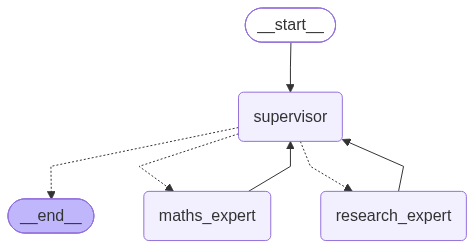

In [10]:
from langgraph_supervisor import create_supervisor

workflow = create_supervisor(
    [reserch_agent, math_agent],
    model = model,
    prompt = (
        "You are a team supervisor managing a research expert and a math expert. "
        "For current events, use research_agent. "
        "For math problems, use math_agent."
    )
)

app = workflow.compile()
app

In [13]:
result = app.invoke({'messages':[HumanMessage('What is Quant Finance')]})
pprint(result)

{'messages': [HumanMessage(content='What is Quant Finance', additional_kwargs={}, response_metadata={}, id='a78f9a16-1006-40c3-ab4e-351415f5a0b4'),
              AIMessage(content=[{'type': 'tool_use', 'name': 'transfer_to_research_expert', 'input': {}, 'id': 'tooluse_6Qrz0ChC4t1Gpf2wIkNTyI'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '89e7809d-67d4-458c-8b8b-5cf511dabea0', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Tue, 18 Aug 2026 10:21:23 GMT', 'content-type': 'application/json', 'content-length': '428', 'connection': 'keep-alive', 'x-amzn-requestid': '89e7809d-67d4-458c-8b8b-5cf511dabea0'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1253]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, name='supervisor', id='lc_run--01a01463-c422-7331-8e5b-4e90c2f2ef3d-0', tool_calls=[{'name': 'transfer_to_research_expert', 'args': {}, 'id': 'tooluse_6Qrz0ChC4t1Gpf2wIkNTyI', 'type': 'tool_c

In [18]:
pprint(result['messages'][-1].content)

('The research expert has provided a comprehensive overview of Quantitative '
 'Finance. To summarize the key takeaway: **Quant Finance is the use of '
 'advanced mathematics, statistics, and computing to solve financial '
 'problems** — from pricing complex derivatives to building algorithmic '
 'trading strategies.\n'
 '\n'
 'Would you like to dive deeper into any specific area, such as:\n'
 '- 📐 The **math behind pricing models** (e.g., Black-Scholes)?\n'
 '- 💻 **Programming for quant finance**?\n'
 '- 🎯 **Career paths** in the field?\n'
 '\n'
 'Just let me know!')


In [19]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Quant Finance
================================== Ai Message ==================================
Name: supervisor

[{'type': 'tool_use', 'name': 'transfer_to_research_expert', 'input': {}, 'id': 'tooluse_6Qrz0ChC4t1Gpf2wIkNTyI'}]
Tool Calls:
  transfer_to_research_expert (tooluse_6Qrz0ChC4t1Gpf2wIkNTyI)
 Call ID: tooluse_6Qrz0ChC4t1Gpf2wIkNTyI
  Args:
================================= Tool Message =================================
Name: transfer_to_research_expert

Successfully transferred to research_expert
================================== Ai Message ==================================
Name: research_expert

## What is Quantitative Finance (Quant Finance)?

**Quantitative Finance**, commonly known as **"Quant Finance"** or simply **"Quant"**, is an interdisciplinary field that combines **mathematics, statistics, computer science, and finance** to analyze financial markets, price financial instrume

In [20]:
result = app.invoke({'messages':[HumanMessage("who is the president of USA in 2025. Add 10 to his age")]})
pprint(result)

{'messages': [HumanMessage(content='who is the president of USA in 2025. Add 10 to his age', additional_kwargs={}, response_metadata={}, id='2fb3ee0a-80af-4054-bb51-ad049f484aab'),
              AIMessage(content=[{'type': 'text', 'text': "I'll handle both tasks simultaneously! Let me consult both the research expert (for the president's identity and age) and the math expert (for the addition) — wait, I first need the president's age before I can do the math. Let me start by getting the research done first!"}, {'type': 'tool_use', 'name': 'transfer_to_research_expert', 'input': {}, 'id': 'tooluse_4dTbKd53LKCWLIT2ufWAfA'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '30ee2369-a144-476d-b60b-75474c45fb88', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Tue, 18 Aug 2026 10:40:24 GMT', 'content-type': 'application/json', 'content-length': '715', 'connection': 'keep-alive', 'x-amzn-requestid': '30ee2369-a144-476d-b60b-75474c45fb88'}, 'RetryAttempts': 0}, 'st

In [21]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

who is the president of USA in 2025. Add 10 to his age
================================== Ai Message ==================================
Name: supervisor

[{'type': 'text', 'text': "I'll handle both tasks simultaneously! Let me consult both the research expert (for the president's identity and age) and the math expert (for the addition) — wait, I first need the president's age before I can do the math. Let me start by getting the research done first!"}, {'type': 'tool_use', 'name': 'transfer_to_research_expert', 'input': {}, 'id': 'tooluse_4dTbKd53LKCWLIT2ufWAfA'}]
Tool Calls:
  transfer_to_research_expert (tooluse_4dTbKd53LKCWLIT2ufWAfA)
 Call ID: tooluse_4dTbKd53LKCWLIT2ufWAfA
  Args:
================================= Tool Message =================================
Name: transfer_to_research_expert

Successfully transferred to research_expert
================================== Ai Message =================